In [11]:
import ast
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [26]:
df_us=df[df['job_country'] == 'United States']
df_skills=df_us.explode('job_skills')
df_skills_count= df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
job_titles= df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
df_job_title_count = df_us['job_title_short'].value_counts().reset_index(name='jobs_total')
df_skills_perc= pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_percent'] = 100* df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

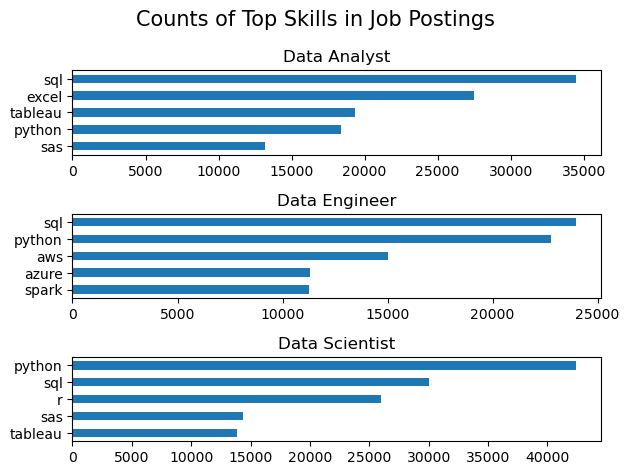

In [21]:
fig,ax= plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot= df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)


fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()

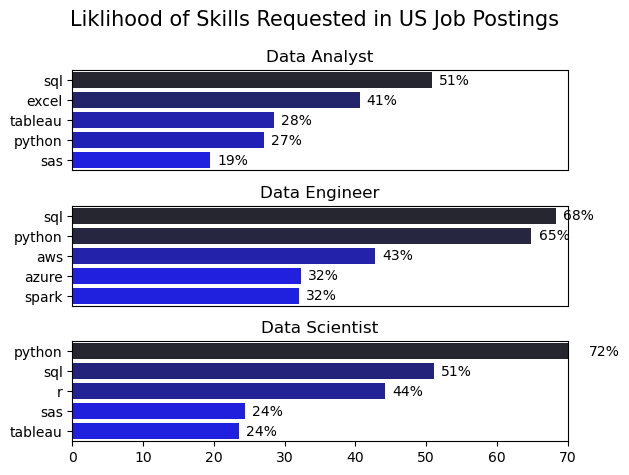

In [39]:
fig,ax= plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot= df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,70)
    ax[i].set_xlabel('')
    ax[i].set_title(job_title)

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v+1, n, f'{v:.0f}%', va='center')

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])


fig.suptitle('Liklihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout()
plt.show()